In [37]:
# ============================================================
# AutoGluon - CICIoT2023
# Classificação com dataset em C:\Dataset\CSV
# ============================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from autogluon.tabular import TabularPredictor

In [38]:
# ============================================================
# 1. Configurações principais
# ============================================================

DATASET_DIR = r"C:\Dataset\CSV"
RESULTS_DIR = r"C:\Dataset\Resultados\AutoGluon"

os.makedirs(RESULTS_DIR, exist_ok=True)
model_name = 'autogluon' # Define o modelo que será utilizado
device = 'cpu' #Define o processador do computador e não a GPU
min_samples_per_class = 5 #Define o mínimo de amostras por classe
n_classes = 2 #Define o número de classes de classificação

#================================================================
# n_classes = 2   # Classificação binária: Benign vs Malicious
# n_classes = 8   # Classificação agrupada
# n_classes = 34  # Classificação multiclasse completa
#=================================================================

n_frac = 0.02 #Define a fração do dataset que será utilizada(2%)
n_trials_tpe = 10 #Define o número de tentativas de otimização
plot_param_importances = False #Define se será gerado um gráfico mostrando a importância dos hiperparâmetros
timeout_tpe = 60 #Define o tempo máximo para a otimização TPE
random_state = 42 #Define a semente aleatória do experimento
n_jobs = -1 #Define que o código poderá usar todos os núcleos disponíveis da CPU

TEST_SIZE = 0.20 #Define o tamanho de amostras de teste

In [39]:
# ============================================================
# 2. Carregar arquivos CSV
# ============================================================

csv_files = glob.glob(os.path.join(DATASET_DIR, "*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(f"Nenhum arquivo CSV encontrado em: {DATASET_DIR}")

print(f"Quantidade de arquivos CSV encontrados: {len(csv_files)}")


lista_dfs = []

for file in csv_files:
    print(f"Lendo arquivo: {os.path.basename(file)}")
    
    df_temp = pd.read_csv(file, low_memory=False)
    
    # Usa apenas uma fração do arquivo para teste rápido
    if n_frac < 1.0:
        df_temp = df_temp.sample(frac=n_frac, random_state=random_state)
    
    lista_dfs.append(df_temp)

df = pd.concat(lista_dfs, ignore_index=True)

print("\nDataset carregado com sucesso.")
print("Dimensão inicial:", df.shape)

Quantidade de arquivos CSV encontrados: 85
Lendo arquivo: Backdoor_Malware.pcap.csv
Lendo arquivo: BenignTraffic.pcap.csv
Lendo arquivo: BenignTraffic1.pcap.csv
Lendo arquivo: BenignTraffic2.pcap.csv
Lendo arquivo: BenignTraffic3.pcap.csv
Lendo arquivo: DoS-UDP_Flood.pcap.csv
Lendo arquivo: DoS-UDP_Flood1.pcap.csv
Lendo arquivo: DoS-UDP_Flood10.pcap.csv
Lendo arquivo: DoS-UDP_Flood11.pcap.csv
Lendo arquivo: DoS-UDP_Flood12.pcap.csv
Lendo arquivo: DoS-UDP_Flood13.pcap.csv
Lendo arquivo: DoS-UDP_Flood14.pcap.csv
Lendo arquivo: DoS-UDP_Flood15.pcap.csv
Lendo arquivo: DoS-UDP_Flood16.pcap.csv
Lendo arquivo: DoS-UDP_Flood2.pcap.csv
Lendo arquivo: DoS-UDP_Flood3.pcap.csv
Lendo arquivo: DoS-UDP_Flood4.pcap.csv
Lendo arquivo: DoS-UDP_Flood5.pcap.csv
Lendo arquivo: DoS-UDP_Flood6.pcap.csv
Lendo arquivo: DoS-UDP_Flood7.pcap.csv
Lendo arquivo: DoS-UDP_Flood8.pcap.csv
Lendo arquivo: DoS-UDP_Flood9.pcap.csv
Lendo arquivo: Merged01.csv
Lendo arquivo: Merged02.csv
Lendo arquivo: Merged03.csv
Lendo ar

In [40]:
# ============================================================
# 3. Detectar coluna de rótulo
# ============================================================

target_candidates = [
    "label", "Label", "Attack", "attack",
    "class", "Class", "Category", "category"
]

LABEL_COL = None

for col in target_candidates:
    if col in df.columns:
        LABEL_COL = col
        break

if LABEL_COL is None:
    raise ValueError(
        "Não foi possível detectar a coluna de rótulo. "
        "Verifique se existe uma coluna chamada label, Label, Attack, class etc."
    )

print(f"\nColuna de rótulo detectada: {LABEL_COL}")


Coluna de rótulo detectada: Label


In [41]:
# ============================================================
# 4. Limpeza básica do dataset
# ============================================================

# Remove espaços extras nos nomes das colunas
df.columns = df.columns.str.strip()

# Remove linhas com rótulo vazio
df = df.dropna(subset=[LABEL_COL])

# Converte infinitos para NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Remove linhas com NaN
df = df.dropna()

print("\nDimensão após limpeza:", df.shape)



Dimensão após limpeza: (900376, 40)


In [42]:
# ============================================================
# 5. Ajustar o problema para n_classes
# ============================================================
#=======================================================================
# Conta amostras por classe
#class_counts = df[LABEL_COL].value_counts()
#
# Mantém apenas classes com amostras mínimas
#valid_classes = class_counts[class_counts >= min_samples_per_class].index
#
#df = df[df[LABEL_COL].isin(valid_classes)].copy()
#
# Seleciona as n_classes mais frequentes
#top_classes = df[LABEL_COL].value_counts().head(n_classes).index
#
#df = df[df[LABEL_COL].isin(top_classes)].copy()
#
#print("\nClasses selecionadas:")
#print(df[LABEL_COL].value_counts())
#==============================================================================




# ============================================================
# 5. Criar classificação binária real: Benign vs Malicious
# ============================================================

# Guarda o nome da coluna original de rótulo
ORIGINAL_LABEL_COL = LABEL_COL

# Remove espaços extras nos valores da coluna de rótulo
df[ORIGINAL_LABEL_COL] = df[ORIGINAL_LABEL_COL].astype(str).str.strip()

# Verificar quais classes existem antes da transformação binária
print("Classes originais encontradas no dataset:")
print(df[ORIGINAL_LABEL_COL].value_counts().head(20))

# Cria uma nova coluna binária:
# Benign serão tratados como tráfego normal
# Todas as demais classes serão tratadas como ataque (Maliciosas)
df["label_binary"] = df[ORIGINAL_LABEL_COL].apply(
    lambda x: "Benign" if x.lower() in ["benigntraffic", "benign", "benign_traffic"] else "Malicious"
)

# Remove a coluna original de rótulo para evitar vazamento de informação
df = df.drop(columns=[ORIGINAL_LABEL_COL])

# Atualizar a coluna de rótulo para o AutoGluon
LABEL_COL = "label_binary"

# Exibe a distribuição das classes binárias
print("\nDistribuição da classificação binária:")
print(df[LABEL_COL].value_counts())

# Validação obrigatória
if df[LABEL_COL].nunique() != 2:
    raise ValueError(
        "Erro: o dataset não possui as duas classes Benign e Malicious. "
        "Verifique se existe BenignTraffic nos arquivos carregados."
    )

Classes originais encontradas no dataset:
Label
DDOS-ICMP_FLOOD            138480
DDOS-UDP_FLOOD             103729
DDOS-TCP_FLOOD              85867
DDOS-PSHACK_FLOOD           78667
DDOS-SYN_FLOOD              77741
DDOS-RSTFINFLOOD            77181
DDOS-SYNONYMOUSIP_FLOOD     68888
DOS-UDP_FLOOD               63209
DOS-TCP_FLOOD               50975
DOS-SYN_FLOOD               38901
BENIGN                      20893
MIRAI-GREETH_FLOOD          18857
MIRAI-UDPPLAIN              16995
MIRAI-GREIP_FLOOD           14542
DDOS-ICMP_FRAGMENTATION      8793
VULNERABILITYSCAN            7131
MITM-ARPSPOOFING             5911
DDOS-ACK_FRAGMENTATION       5551
DDOS-UDP_FRAGMENTATION       5466
DNS_SPOOFING                 3422
Name: count, dtype: int64

Distribuição da classificação binária:
label_binary
Malicious    879483
Benign        20893
Name: count, dtype: int64


In [43]:
# ============================================================
# 6. Separar treino e teste
# ============================================================

train_data, test_data = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=random_state,
    stratify=df[LABEL_COL]
)

print("\nTamanho do treino:", train_data.shape)
print("Tamanho do teste :", test_data.shape)

print("\nDistribuição das classes no treino:")
print(train_data[LABEL_COL].value_counts())

print("\nDistribuição das classes no teste:")
print(test_data[LABEL_COL].value_counts())


Tamanho do treino: (720300, 40)
Tamanho do teste : (180076, 40)

Distribuição das classes no treino:
label_binary
Malicious    703586
Benign        16714
Name: count, dtype: int64

Distribuição das classes no teste:
label_binary
Malicious    175897
Benign         4179
Name: count, dtype: int64


In [44]:
# ============================================================
# 7. Configurar AutoGluon
# ============================================================

if device == "cpu":
    num_gpus = 0
else:
    num_gpus = "auto"

if n_jobs == -1:
    num_cpus = "auto"
else:
    num_cpus = n_jobs

# ------------------------------------------------------------
# Definir se o AutoGluon usará somente XGBoost ou vários modelos
# ------------------------------------------------------------

USE_ONLY_XGBOOST = True

if USE_ONLY_XGBOOST:
    # Usa apenas o modelo XGBoost dentro do AutoGluon
    hyperparameters = {
        "XGB": {}
    }
else:
    # Usa vários modelos automáticos do AutoGluon
    hyperparameters = {
        "GBM": {}, #Gradient Boosting Machine
        "XGB": {}, #XGBoost
        "RF": {}, #Random Forest
        "XT": {}, #Extra Trees
        "CAT": {}, #CatBoost
        "NN_TORCH": {}, #Rede Neural usando PyTorch
      
    }

# HPO: número de tentativas de otimização
hyperparameter_tune_kwargs = {
    "num_trials": n_trials_tpe,
    "scheduler": "local",
    "searcher": "auto"
}

print(f"CPUs utilizadas: {num_cpus}")
print(f"GPUs utilizadas: {num_gpus}")

CPUs utilizadas: auto
GPUs utilizadas: 0


In [45]:
# ============================================================
# 8. Treinar modelo com AutoGluon - Classificação Binária
# ============================================================

predictor = TabularPredictor(
    label=LABEL_COL,
    problem_type="binary",
    eval_metric="f1",
    path=RESULTS_DIR,
    learner_kwargs={
        "label_count_threshold": min_samples_per_class
    }
)

predictor.fit(
    train_data=train_data,
    time_limit=timeout_tpe,
    presets="medium_quality",
    hyperparameters=hyperparameters,
    hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
    num_cpus=num_cpus,
    num_gpus=num_gpus
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       5.39 GB / 15.88 GB (34.0%)
Disk Space Avail:   234.87 GB / 930.66 GB (25.2%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "C:\Dataset\Resultados\AutoGluon"
Train Data Rows:    720300
Train Data Columns: 39
Label Column:       label_binary
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = Malicious, class 0 = Benign
	Note: For your binary classification, AutoGluon arbitrarily selected which label-value represents positive (Malicious) vs negative (Benign) class.
	To explicitly set the positive_class, either rename classes to 1 and 0, or spec

  0%|          | 0/10 [00:00<?, ?it/s]

Fitted model: XGBoost\T1 ...
	0.9966	 = Validation score   (f1)
	6.17s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: XGBoost\T2 ...
	0.9964	 = Validation score   (f1)
	3.8s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: XGBoost\T3 ...
	0.9883	 = Validation score   (f1)
	2.18s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: XGBoost\T4 ...
	0.9966	 = Validation score   (f1)
	9.05s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: XGBoost\T5 ...
	0.9966	 = Validation score   (f1)
	4.36s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: XGBoost\T6 ...
	0.9963	 = Validation score   (f1)
	7.76s	 = Training   runtime
	0.04s	 = Validation runtime
Fitted model: XGBoost\T7 ...
	0.9883	 = Validation score   (f1)
	2.19s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 57.24s of the 9.50s of remaining time.
	Fitting 1 model on all data | Fitting with 

In [46]:
# ============================================================
# 9. Leaderboard dos modelos
# ============================================================

# Gera a tabela de classificação dos modelos treinados
leaderboard = predictor.leaderboard(test_data, silent=True)

print("\n====================================================")
print("LEADERBOARD - AUTOGLUON")
print("====================================================")
print(leaderboard)

leaderboard_path = os.path.join(RESULTS_DIR, "leaderboard_autogluon.csv")
leaderboard.to_csv(leaderboard_path, index=False)

print(f"\nLeaderboard salvo em: {leaderboard_path}")




LEADERBOARD - AUTOGLUON
                 model  score_test  score_val eval_metric  pred_time_test  \
0           XGBoost\T1    0.996156   0.996553          f1        0.308256   
1           XGBoost\T5    0.996073   0.996555          f1        0.248851   
2  WeightedEnsemble_L2    0.995994   0.996732          f1        0.833679   
3           XGBoost\T4    0.995976   0.996624          f1        0.313960   
4           XGBoost\T6    0.995865   0.996340          f1        0.294910   
5           XGBoost\T2    0.995685   0.996377          f1        0.257758   
6           XGBoost\T7    0.988260   0.988272          f1        0.219010   
7           XGBoost\T3    0.988260   0.988272          f1        0.220401   

   pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0       0.022869   6.165442                 0.308256                0.022869   
1       0.023107   4.357483                 0.248851                0.023107   
2       0.076096  17.525289              

In [47]:
# ============================================================
# 10. Predição no conjunto de teste
# ============================================================

X_test = test_data.drop(columns=[LABEL_COL])
y_test = test_data[LABEL_COL]

y_pred = predictor.predict(X_test)

In [48]:
# ============================================================
# 11. Métricas de avaliação
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\n====================================================")
print("RESULTADOS - AUTOGLUON")
print("====================================================")
print(f"Accuracy          : {accuracy:.6f}")
print(f"Balanced Accuracy : {balanced_acc:.6f}")
print(f"Precision         : {precision:.6f}")
print(f"Recall            : {recall:.6f}")
print(f"F1-score          : {f1:.6f}")

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, zero_division=0))


RESULTADOS - AUTOGLUON
Accuracy          : 0.992176
Balanced Accuracy : 0.918321
Precision         : 0.992251
Recall            : 0.992176
F1-score          : 0.992211

Relatório de classificação:
              precision    recall  f1-score   support

      Benign       0.83      0.84      0.83      4179
   Malicious       1.00      1.00      1.00    175897

    accuracy                           0.99    180076
   macro avg       0.91      0.92      0.91    180076
weighted avg       0.99      0.99      0.99    180076



In [49]:
# Salvar relatório em TXT
report_path = os.path.join(RESULTS_DIR, "classification_report_autogluon.txt")

with open(report_path, "w", encoding="utf-8") as f:
    f.write("RESULTADOS - AUTOGLUON\n")
    f.write("====================================================\n")
    f.write(f"Accuracy          : {accuracy:.6f}\n")
    f.write(f"Balanced Accuracy : {balanced_acc:.6f}\n")
    f.write(f"Precision         : {precision:.6f}\n")
    f.write(f"Recall            : {recall:.6f}\n")
    f.write(f"F1-score          : {f1:.6f}\n\n")
    f.write("Relatório de classificação:\n")
    f.write(classification_report(y_test, y_pred, zero_division=0))

print(f"\nRelatório salvo em: {report_path}")


Relatório salvo em: C:\Dataset\Resultados\AutoGluon\classification_report_autogluon.txt


<Figure size 1000x800 with 0 Axes>

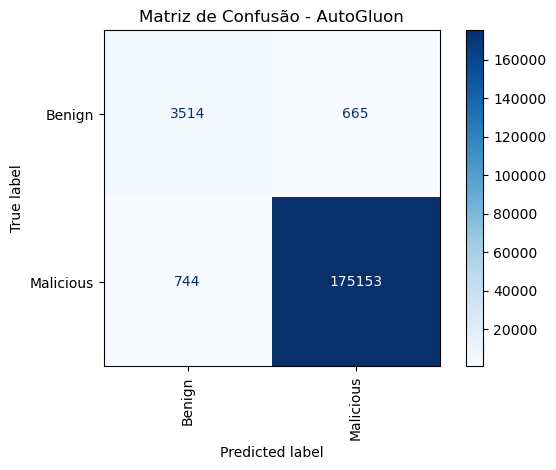

Matriz de confusão salva em: C:\Dataset\Resultados\AutoGluon\matriz_confusao_autogluon.png


In [50]:
# ============================================================
# 12. Matriz de confusão
# ============================================================

classes = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Matriz de Confusão - AutoGluon")
plt.tight_layout()

cm_path = os.path.join(RESULTS_DIR, "matriz_confusao_autogluon.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Matriz de confusão salva em: {cm_path}")